In [28]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import skactiveml
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, ElementFraction
from matminer.featurizers.base import MultipleFeaturizer
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Config
CSV_PATH = '../data/hse_df_feat/hse_df_feat.csv'
TARGET_COL = 'dG_hse06 (eV/atom)'

BLACKLIST_COLS = ['dH_hse06 (eV/atom)','dG_hse06 (eV/atom)','formula','reduced_formula','composition']
Magpie_features = ElementProperty.from_preset('magpie').feature_labels()
innate_features = [
    'formula',
    'reduced_formula',
    'dH_hse06 (eV/atom)',
    'dG_hse06 (eV/atom)',
    'r_s (AA)',
    'r_val (AA)',
    'e_H (eV)',
    'e_L (eV)',
    'AN',
    'IP (eV)',
    'EA (eV)',
    'r_cov (AA)',
    'EN (Pauling)',
    'N_val',
    'N_unf',
    'max_OS',
    'stdev_OS',
]
features_full = innate_features + Magpie_features
features = [c for c in features_full if c not in BLACKLIST_COLS]

def build_X(df, scaler=StandardScaler(), train=False, raw=False):
    '''
    Build X with scaled continuous part and fingerprints.

    Args:
        df: dataframe with a 'smiles' column and qm9_features columns
        scaler: fitted scaler, or None to create a StandardScaler
        train: if True, fit scaler on continuous features
        raw: if True, return unscaled X
        n_jobs: number of CPU cores to use for fingerprinting

    Returns:
        X: feature matrix
    '''
    df = df.copy()
    X = df[features].to_numpy()

    if raw:
        return X

    X = (
        scaler.fit_transform(X) if train
        else scaler.transform(X)
    )

    return X

def plot_prediction(X, y, model, model_name=None, name=TARGET_COL, figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predictions for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        model_name: Name of the model (str).
        name: Name of the target value (str).
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    y_pred = model.predict(X)
    errors = np.abs(y - y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y, y_pred, c=errors, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    if model_name is None:
        ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    else:
        ax.set_title(f'{name} {model_name} prediction plot')
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mean_absolute_error(y,y_pred):.4f}')
    print(f'MSE = {mean_squared_error(y,y_pred):.4f}')
    print(f'RMSE = {root_mean_squared_error(y,y_pred):.4f}')
    print(f'r^2 = {r2_score(y,y_pred):.4f}')

def print_cross_val(X, y, model, splits=5, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        n_splits: Number of CV splits (int).
        random_state: Random state seed (int).
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae':  'neg_mean_absolute_error',
        'mse':  'neg_mean_sqared_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)

    print('Cross-validation scores:')
    print(f'Mean MAE  = {np.mean(np.abs(results['test_mae'])):.4f}')
    print(f'Mean MSE  = {np.mean(np.abs(results['test_mse'])):.4f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.4f}')
    print(f'Mean R²   = {np.mean(results['test_r2']):.4f}')

def plot_violin(X, y, models, metric='rmse', target_name=TARGET_COL, splits=5, y_min=0, y_max=None, figsize=(10, 6)):
    '''
    Plot RMSE violin plot for given models and data.

    Args:
        X           : Input features (np.array).
        y           : True target values (np.array).
        models      : List of unfitted model instances (list).
        target_name : Label for plot title (str).
        splits      : Number of CV splits (int).
        y_min       : Y-axis min value (float).
        y_max       : Y-axis max value (float).
        metric      : 'rsr' or 'rmse' (str)
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    records = []
    for model in models:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        if metric == 'rmse':
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RMSE': -score})
        else:
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
                
    df_plot = pd.dataFrame(records)

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df_plot,
        y='RMSE' if metric == 'rmse' else 'RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{target_name}\nModel Comparison — CV RMSE Scores' if metric == 'rmse' else f'{target_name}\nModel Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

#### Import dataset `hse_df_feat.csv`
Target variables
- **dH_hse06:** Formation Enthalpy
- **dG_hse06:** Formation Gibbs free energy

Features
- **r_s:** Wigner-Seitz radius?
- **r_val:** Valence radius
- **r_cov:** Covalent radius
- **e_H:** HOMO Energy
- **e_L:** LUMO Energy
- **AN:** Atomic number
- **IP:** Ionisation potential
- **EA:** Electron affinity
- **EN:** Electronegativity
- **N_val:** Valence electrons
- **N_unf:** Unfilled electrons
- **max_OS:** Maximum oxidation state
- **stdev_OS:** Standard deviation of oxidation states

In [29]:
# Load
df_train = pd.read_csv('../data/hse_df_feat/dg/hse_df_feat_dg_train.csv')
df_test = pd.read_csv('../data/hse_df_feat/dg/hse_df_feat_dg_test.csv')
df_val = pd.read_csv('../data/hse_df_feat/dg/hse_df_feat_dg_val.csv')

X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
# X_cv = build_X(df_train, raw=True)
# X = build_X(df, raw=True)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
# y = df[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
# print(f'Full set Molecules: {X.shape[0]}  |  Features: {X.shape[1]}')

Train set Molecules: 5496  |  Features: 145
Test set Molecules: 687  |  Features: 145
Validate set Molecules: 687  |  Features: 145


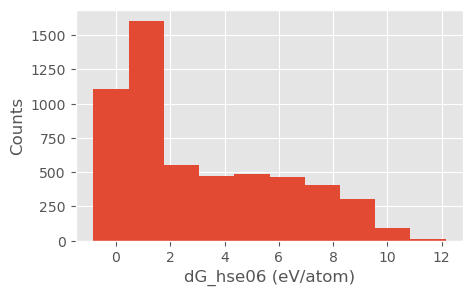

In [30]:
# Plot train histogram
plt.figure(figsize=(5,3))
plt.hist(df_train[TARGET_COL], bins=10)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

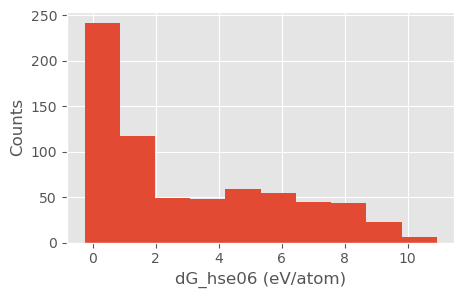

In [31]:
# Plot test histogram
plt.figure(figsize=(5,3))
plt.hist(df_test[TARGET_COL], bins=10)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

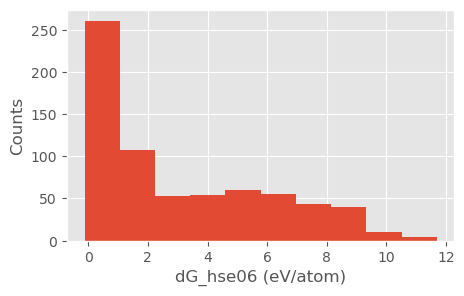

In [32]:
# Plot val histogram
plt.figure(figsize=(5,3))
plt.hist(df_val[TARGET_COL], bins=10)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

## Baseline

### Train models

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train,y_train)
joblib.dump(rf, 'models/rf/hse_df_feat/rf_dG_hse_df_feat.pkl')

['models/rf/hse_df_feat/rf_dG_hse_df_feat.pkl']

In [34]:
from sklearn.kernel_ridge import KernelRidge
kr = KernelRidge(
    alpha=0.01,
    gamma=0.01,
    kernel='laplacian',
)
kr.fit(X_train,y_train)
joblib.dump(kr, 'models/kr/hse_df_feat/kr_dG_hse_df_feat.pkl')

['models/kr/hse_df_feat/kr_dG_hse_df_feat.pkl']

In [35]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=3,
    n_estimators=500,
    reg_alpha=1.0,
    reg_lambda=1.0,
    subsample=0.6,
)
xgb.fit(X_train,y_train)
joblib.dump(xgb, 'models/xgb/hse_df_feat/xgb_dG_hse_df_feat.pkl')

['models/xgb/hse_df_feat/xgb_dG_hse_df_feat.pkl']

In [36]:
from sklearn.ensemble import VotingRegressor
com = VotingRegressor(
    estimators=[
        ('rf', clone(rf)),
        ('xgb', clone(xgb)),
        ('kr', clone(kr)),
    ],
    n_jobs=-1,
)
com.fit(X_train,y_train)
joblib.dump(com, 'models/com/hse_df_feat/com_dG_hse_df_feat.pkl')

['models/com/hse_df_feat/com_dG_hse_df_feat.pkl']

### Load models

In [37]:
rf = joblib.load('models/rf/hse_df_feat/rf_dG_hse_df_feat.pkl') #RandomForestRegressor
kr = joblib.load('models/kr/hse_df_feat/kr_dG_hse_df_feat.pkl') #KernelRidge
xgb= joblib.load('models/xgb/hse_df_feat/xgb_dG_hse_df_feat.pkl') #XGBRegressor
com= joblib.load('models/com/hse_df_feat/com_dG_hse_df_feat.pkl') #Committee VotingRegressor of models above

In [38]:
# Score of the model
rf_pred_test = rf.predict(X_test)
rf_pred_val = rf.predict(X_val)
rf_score = {
    'mae_test': mean_absolute_error(y_test, rf_pred_test),
    'rmse_test': root_mean_squared_error(y_test, rf_pred_test),
    'r2_test':  r2_score(y_test, rf_pred_test),
    'mae_val': mean_absolute_error(y_val, rf_pred_val),
    'rmse_val':  root_mean_squared_error(y_val, rf_pred_val),
    'r2_val':   r2_score(y_val, rf_pred_val),
}
print(rf_score)

kr_pred_test = kr.predict(X_test)
kr_pred_val = kr.predict(X_val)
kr_score = {
    'mae_test': mean_absolute_error(y_test, kr_pred_test),
    'rmse_test': root_mean_squared_error(y_test, kr_pred_test),
    'r2_test': r2_score(y_test, kr_pred_test),
    'mae_val': mean_absolute_error(y_val, kr_pred_val),
    'rmse_val': root_mean_squared_error(y_val, kr_pred_val),
    'r2_val': r2_score(y_val, kr_pred_val),
}
print(kr_score)

xgb_pred_test = xgb.predict(X_test)
xgb_pred_val = xgb.predict(X_val)
xgb_score = {
    'mae_test': mean_absolute_error(y_test, xgb_pred_test),
    'rmse_test': root_mean_squared_error(y_test, xgb_pred_test),
    'r2_test': r2_score(y_test, xgb_pred_test),
    'mae_val': mean_absolute_error(y_val, xgb_pred_val),
    'rmse_val': root_mean_squared_error(y_val, xgb_pred_val),
    'r2_val': r2_score(y_val, xgb_pred_val),
}
print(xgb_score)

com_pred_test = com.predict(X_test)
com_pred_val = com.predict(X_val)
com_score = {
    'mae_test': mean_absolute_error(y_test, com_pred_test),
    'rmse_test': root_mean_squared_error(y_test, com_pred_test),
    'r2_test': r2_score(y_test, com_pred_test),
    'mae_val': mean_absolute_error(y_val, com_pred_val),
    'rmse_val': root_mean_squared_error(y_val, com_pred_val),
    'r2_val': r2_score(y_val, com_pred_val),
}
print(com_score)


{'mae_test': 0.2249074292022223, 'rmse_test': 0.3531018786522704, 'r2_test': 0.9851165724556666, 'mae_val': 0.24093377261735396, 'rmse_val': 0.3717913822490883, 'r2_val': 0.9839209289505677}
{'mae_test': 0.1386801617297362, 'rmse_test': 0.21786152912146847, 'r2_test': 0.9943341640433064, 'mae_val': 0.15012598390182758, 'rmse_val': 0.23548465694310836, 'r2_val': 0.9935495866172496}
{'mae_test': 0.1806213661279079, 'rmse_test': 0.26522560972420844, 'r2_test': 0.9916028132056084, 'mae_val': 0.17848180165632402, 'rmse_val': 0.26934057727425137, 'r2_val': 0.991561487668534}
{'mae_test': 0.15797230078802374, 'rmse_test': 0.24261461545794744, 'r2_test': 0.9929735360749617, 'mae_val': 0.16530167484711739, 'rmse_val': 0.2533871137739147, 'r2_val': 0.992531534734233}


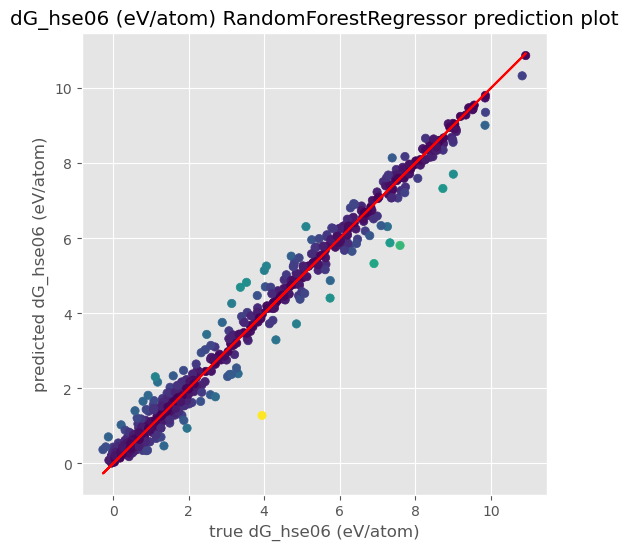

Training scores:
MAE = 0.2249
MSE = 0.1247
RMSE = 0.3531
r^2 = 0.9851


In [47]:
plot_prediction(X_test, y_test, rf, save='models/rf/hse_df_feat/rf_dG_hse_df_feat_plot.png', format='png')

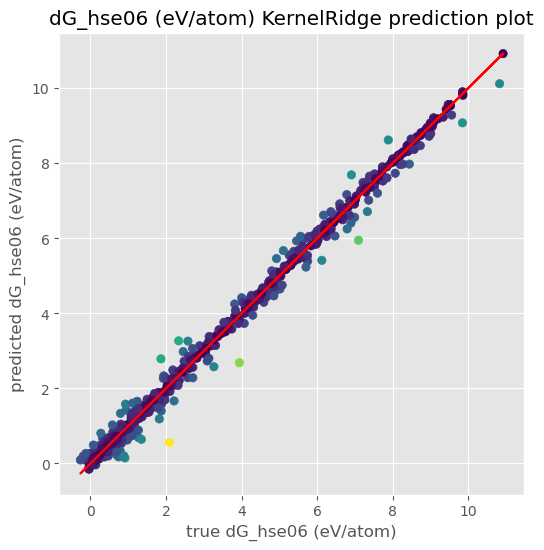

Training scores:
MAE = 0.1387
MSE = 0.0475
RMSE = 0.2179
r^2 = 0.9943


In [46]:
plot_prediction(X_test, y_test, kr, save='models/kr/hse_df_feat/kr_dG_hse_df_feat_plot.png', format='png')

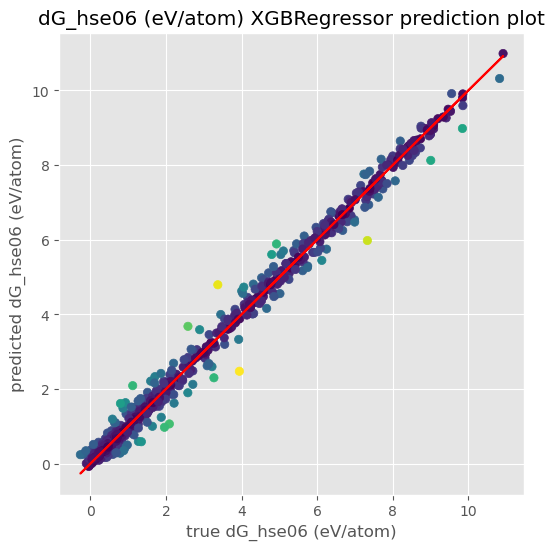

Training scores:
MAE = 0.1806
MSE = 0.0703
RMSE = 0.2652
r^2 = 0.9916


In [45]:
plot_prediction(X_test, y_test, xgb, save='models/xgb/hse_df_feat/xgb_dG_hse_df_feat_plot.png', format='png')

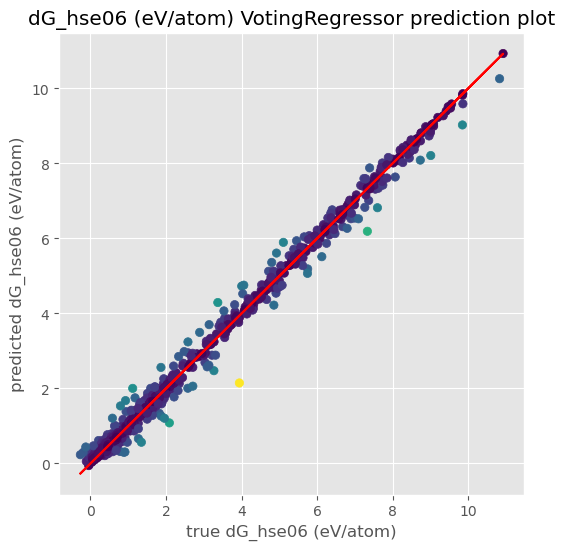

Training scores:
MAE = 0.1580
MSE = 0.0589
RMSE = 0.2426
r^2 = 0.9930


In [44]:
plot_prediction(X_test, y_test, com, save='models/com/hse_df_feat/com_dG_hse_df_feat_plot.png', format='png')

# AL Query strategies

In [48]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import RandomSampling
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_rnd(
    model,
    n_initial=496,
    batch_size=500,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Random sampling active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
                
            if len(unlabeled_idx) == 0:    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx = rnd.query(X=X_train, y=y_pool, batch_size=batch_size)
            
            y_pool[query_idx] = y_train[query_idx]
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [49]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_unc(
    model,
    bagging_estimators=5,
    n_initial=496,
    batch_size=500,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee Bagging Regressor) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        bagging_estimators: Number of estimators in the bagging committee (int).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                BaggingRegressor(
                    estimator=reg,   
                    n_estimators=bagging_estimators,
                    bootstrap=True,
                    random_state=random_state,
                )
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [50]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_qbc(
    model,
    n_initial=496,
    batch_size=500,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee with heterogeneous models) active learning loop over a regression task.

    Args:
        models: Committee models of several base estimators (sklearn VotingRegressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                estimator=reg, random_state=random_state
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [73]:
from sklearn.base import clone
from skactiveml.regressor import SklearnRegressor
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def diversity_query(
    X_train: np.ndarray,
    y_pool: np.ndarray,
    batch_size: int,
):
    '''
    Select a batch of unlabeled samples using greedy MaxMin diversity sampling with Tanimoto distance.

    Args:
        X_train: Training feature matrix with only fingerprints (np.ndarray).
        y_pool: Current label pool. Unlabeled entries are marked with MISSING_LABEL (np.ndarray).
        batch_size: Number of samples to select (int).
    Returns:
        query_idx: Queried indices, ordered from most to least diverse (np.ndarray).
        utilities:
            - div_mean_pool: Mean Tanimoto distance of all unlabeled points to their nearest labeled neighbour.
            - div_max_pool: Maximum Tanimoto distance in the unlabeled pool, i.e. the distance of the most underexplored point.
    '''
    labeled_idx   = labeled_indices(y_pool)
    unlabeled_idx = unlabeled_indices(y_pool)

    if len(unlabeled_idx) == 0:
        return np.array([], dtype=int), {}

    actual_batch = min(batch_size, len(unlabeled_idx))

    # binarize once, float32 halves memory + speeds up BLAS
    X_u = (X_train[unlabeled_idx] > 0).astype(np.float32)
    X_l = (X_train[labeled_idx]   > 0).astype(np.float32)

    # precompute norms once — reused in every greedy step
    norms_u = X_u.sum(axis=1)  # (n_unlabeled,)
    norms_l = X_l.sum(axis=1)  # (n_labeled,)

    # initial max similarity to labeled set — single matmul
    dot   = X_u @ X_l.T                              # (n_u, n_l)
    union = norms_u[:, None] + norms_l[None, :] - dot
    np.maximum(union, 1e-10, out=union)               # in-place, no allocation
    max_sim = (dot / union).max(axis=1)               # (n_u,)
    del dot, union                                    # free memory immediately

    dist_orig = 1.0 - max_sim.copy()

    selected_local: list[int] = []

    for _ in range(actual_batch):
        best = int(np.argmin(max_sim))
        selected_local.append(best)
        max_sim[best] = np.inf

        if len(selected_local) < actual_batch:
            # matvec (n_u × d) instead of matmul (n_u × n_u) — much cheaper
            dot_new   = X_u @ X_u[best]              # (n_u,)
            union_new = norms_u + norms_u[best] - dot_new
            np.maximum(union_new, 1e-10, out=union_new)
            np.maximum(max_sim, dot_new / union_new, out=max_sim)

    utilities = {
        'mean_diversity': float(dist_orig.mean()),
        'max_diversity':  float(dist_orig.max()),
    }

    return unlabeled_idx[np.array(selected_local)], utilities
    
def al_loop_div(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Diversity sampling (Tanimoto distance) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_diversity': [],
            'max_diversity': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:    
                history['mean_diversity'].append(0.0)
                history['max_diversity'].append(0.0)
                
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Diversity — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx, utilities = diversity_query(X_train[:, (slice(len(features), None))], y_pool, batch_size)
            
            y_pool[query_idx] = y_train[query_idx]

            history['mean_diversity'].append(utilities['mean_diversity'])
            history['max_diversity'].append(utilities['max_diversity'])
            
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Diversity — mean: {utilities['mean_diversity']:.4f}  '
                f'max: {utilities['max_diversity']:.4f}'
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [51]:
al_loop_rnd(rf, n_runs=5, save='active_learning/rf/hse_df_feat/al_history_rf_rnd_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.4857 eV | RMSE: 0.7089 eV | R2: 0.9400 | 
Cycle  2 | Labeled:   996/5496 | MAE: 0.3998 eV | RMSE: 0.5934 eV | R2: 0.9580 | 
Cycle  3 | Labeled:  1496/5496 | MAE: 0.3527 eV | RMSE: 0.5157 eV | R2: 0.9683 | 
Cycle  4 | Labeled:  1996/5496 | MAE: 0.3305 eV | RMSE: 0.4944 eV | R2: 0.9708 | 
Cycle  5 | Labeled:  2496/5496 | MAE: 0.2968 eV | RMSE: 0.4553 eV | R2: 0.9753 | 
Cycle  6 | Labeled:  2996/5496 | MAE: 0.2815 eV | RMSE: 0.4401 eV | R2: 0.9769 | 
Cycle  7 | Labeled:  3496/5496 | MAE: 0.2658 eV | RMSE: 0.4236 eV | R2: 0.9786 | 
Cycle  8 | Labeled:  3996/5496 | MAE: 0.2534 eV | RMSE: 0.4044 eV | R2: 0.9805 | 
Cycle  9 | Labeled:  4496/5496 | MAE: 0.2413 eV | RMSE: 0.3821 eV | R2: 0.9826 | 
Cycle 10 | Labeled:  4996/5496 | MAE: 0.2350 eV | RMSE: 0.3740 eV | R2: 0.9833 | 
Cycle 11 | Labeled:  5496/5496 | MAE: 0.2249 eV | RMSE: 0.3531 eV | R2: 0.9851 | 
All pool samples labeled.

Done. Final labeled count: 5496/5496

Run 2/

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,496,0.485665,0.502571,0.708922,0.940007,0.506372,0.539615,0.734585,0.937231,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.399752,0.352128,0.593404,0.957966,0.404640,0.373695,0.611306,0.956531,"[2106, 3885, 195, 4885, 2863, 495, 2919, 1546,..."
2,1,3,1496,0.352652,0.265958,0.515711,0.968252,0.355226,0.275474,0.524856,0.967956,"[3328, 4000, 5253, 3623, 2989, 4400, 1123, 751..."
3,1,4,1996,0.330495,0.244459,0.494428,0.970818,0.331179,0.243085,0.493037,0.971724,"[4354, 5121, 137, 1416, 403, 4305, 925, 4009, ..."
4,1,5,2496,0.296769,0.207310,0.455313,0.975253,0.309367,0.216770,0.465586,0.974785,"[328, 1428, 4362, 2609, 487, 900, 4296, 1097, ..."
5,1,6,2996,0.281544,0.193730,0.440148,0.976874,0.293235,0.195453,0.442100,0.977265,"[1873, 2839, 706, 5392, 4669, 303, 110, 599, 2..."
6,1,7,3496,0.265821,0.179451,0.423616,0.978579,0.274802,0.175326,0.418720,0.979606,"[4685, 3668, 1856, 5298, 1054, 1084, 2467, 749..."
7,1,8,3996,0.253396,0.163523,0.404380,0.980480,0.263304,0.166254,0.407743,0.980661,"[10, 4343, 4045, 4043, 2038, 2708, 2734, 3384,..."
8,1,9,4496,0.241293,0.145997,0.382096,0.982572,0.254777,0.155400,0.394208,0.981924,"[1906, 1229, 2977, 3181, 1714, 844, 5255, 298,..."
9,1,10,4996,0.235042,0.139860,0.373979,0.983305,0.243697,0.145142,0.380975,0.983117,"[4083, 1663, 3395, 993, 3942, 2485, 2903, 4819..."


In [52]:
al_loop_unc(rf, n_runs=5, save='active_learning/rf/hse_df_feat/al_history_rf_unc_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.4857 eV | RMSE: 0.7089 eV | R2: 0.9400 | Uncertainty — mean: 0.7737 eV  max: 1.0852 eV
Cycle  2 | Labeled:   996/5496 | MAE: 0.4292 eV | RMSE: 0.6277 eV | R2: 0.9530 | Uncertainty — mean: 0.6117 eV  max: 0.8731 eV
Cycle  3 | Labeled:  1496/5496 | MAE: 0.3830 eV | RMSE: 0.5412 eV | R2: 0.9650 | Uncertainty — mean: 0.5250 eV  max: 0.8397 eV
Cycle  4 | Labeled:  1996/5496 | MAE: 0.3299 eV | RMSE: 0.4613 eV | R2: 0.9746 | Uncertainty — mean: 0.4758 eV  max: 0.6927 eV
Cycle  5 | Labeled:  2496/5496 | MAE: 0.2977 eV | RMSE: 0.4223 eV | R2: 0.9787 | Uncertainty — mean: 0.3952 eV  max: 0.6188 eV
Cycle  6 | Labeled:  2996/5496 | MAE: 0.2761 eV | RMSE: 0.3967 eV | R2: 0.9812 | Uncertainty — mean: 0.3575 eV  max: 0.5752 eV
Cycle  7 | Labeled:  3496/5496 | MAE: 0.2585 eV | RMSE: 0.3768 eV | R2: 0.9830 | Uncertainty — mean: 0.3154 eV  max: 0.5858 eV
Cycle  8 | Labeled:  3996/5496 | MAE: 0.2434 eV | RMSE: 0.3655 eV | R2: 0.9841 | Unc

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,496,0.485665,0.502571,0.708922,0.940007,0.506372,0.539615,0.734585,0.937231,0.598541,1.177558,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.429204,0.393994,0.627690,0.952968,0.453442,0.402018,0.634049,0.953236,0.374120,0.762295,"[3031, 4592, 967, 894, 1721, 4524, 2702, 3549,..."
2,1,3,1496,0.383044,0.292916,0.541217,0.965034,0.409085,0.332323,0.576474,0.961344,0.275638,0.705090,"[1904, 1543, 3011, 3189, 1843, 4764, 4805, 247..."
3,1,4,1996,0.329931,0.212835,0.461340,0.974593,0.329926,0.214804,0.463470,0.975014,0.226401,0.479786,"[3483, 4167, 4886, 3359, 2757, 1079, 1383, 175..."
4,1,5,2496,0.297673,0.178370,0.422339,0.978708,0.307172,0.189982,0.435869,0.977901,0.156150,0.382926,"[4532, 2705, 959, 3471, 5354, 1300, 4142, 4254..."
5,1,6,2996,0.276137,0.157368,0.396697,0.981215,0.284107,0.165845,0.407241,0.980709,0.127778,0.330878,"[5198, 2683, 1924, 1570, 1644, 1850, 5253, 194..."
6,1,7,3496,0.258545,0.141995,0.376822,0.983050,0.269895,0.153935,0.392345,0.982094,0.099491,0.343131,"[5398, 3730, 5293, 2540, 2082, 4547, 1550, 390..."
7,1,8,3996,0.243423,0.133586,0.365495,0.984054,0.255644,0.143957,0.379417,0.983255,0.069186,0.182943,"[4924, 219, 5320, 1295, 3997, 73, 3621, 5003, ..."
8,1,9,4496,0.240458,0.131825,0.363077,0.984264,0.251109,0.142097,0.376958,0.983471,0.054514,0.178163,"[2379, 5407, 3012, 839, 1947, 1096, 3971, 1250..."
9,1,10,4996,0.230964,0.127560,0.357155,0.984773,0.244432,0.138400,0.372022,0.983901,0.030734,0.092149,"[2970, 3078, 1902, 3979, 5389, 1798, 2074, 481..."


In [53]:
al_loop_rnd(xgb, n_runs=5, save='active_learning/xgb/hse_df_feat/al_history_xgb_rnd_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3786 eV | RMSE: 0.5695 eV | R2: 0.9613 | 
Cycle  2 | Labeled:   996/5496 | MAE: 0.2877 eV | RMSE: 0.4262 eV | R2: 0.9783 | 
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2550 eV | RMSE: 0.3850 eV | R2: 0.9823 | 
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2432 eV | RMSE: 0.3597 eV | R2: 0.9846 | 
Cycle  5 | Labeled:  2496/5496 | MAE: 0.2232 eV | RMSE: 0.3333 eV | R2: 0.9867 | 
Cycle  6 | Labeled:  2996/5496 | MAE: 0.2073 eV | RMSE: 0.3200 eV | R2: 0.9878 | 
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1964 eV | RMSE: 0.2994 eV | R2: 0.9893 | 
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1865 eV | RMSE: 0.2857 eV | R2: 0.9903 | 
Cycle  9 | Labeled:  4496/5496 | MAE: 0.1859 eV | RMSE: 0.2886 eV | R2: 0.9901 | 
Cycle 10 | Labeled:  4996/5496 | MAE: 0.1809 eV | RMSE: 0.2690 eV | R2: 0.9914 | 
Cycle 11 | Labeled:  5496/5496 | MAE: 0.1806 eV | RMSE: 0.2652 eV | R2: 0.9916 | 
All pool samples labeled.

Done. Final labeled count: 5496/5496

Run 2/

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,496,0.378614,0.324285,0.569460,0.961289,0.387769,0.324211,0.569395,0.962287,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.287725,0.181637,0.426189,0.978318,0.292353,0.188088,0.433691,0.978121,"[2106, 3885, 195, 4885, 2863, 495, 2919, 1546,..."
2,1,3,1496,0.254975,0.148249,0.385031,0.982303,0.250302,0.136788,0.369848,0.984089,"[3328, 4000, 5253, 3623, 2989, 4400, 1123, 751..."
3,1,4,1996,0.243207,0.129412,0.359739,0.984552,0.234513,0.119312,0.345416,0.986121,"[4354, 5121, 137, 1416, 403, 4305, 925, 4009, ..."
4,1,5,2496,0.223159,0.111076,0.333281,0.986741,0.216072,0.103355,0.321489,0.987978,"[328, 1428, 4362, 2609, 487, 900, 4296, 1097, ..."
5,1,6,2996,0.207299,0.102385,0.319977,0.987778,0.205289,0.093587,0.305920,0.989114,"[1873, 2839, 706, 5392, 4669, 303, 110, 599, 2..."
6,1,7,3496,0.196374,0.089612,0.299353,0.989303,0.196745,0.087849,0.296393,0.989781,"[4685, 3668, 1856, 5298, 1054, 1084, 2467, 749..."
7,1,8,3996,0.186523,0.081597,0.285652,0.990260,0.194642,0.084411,0.290536,0.990181,"[10, 4343, 4045, 4043, 2038, 2708, 2734, 3384,..."
8,1,9,4496,0.185868,0.083301,0.288619,0.990056,0.195500,0.083121,0.288307,0.990331,"[1906, 1229, 2977, 3181, 1714, 844, 5255, 298,..."
9,1,10,4996,0.180882,0.072355,0.268988,0.991363,0.182949,0.072883,0.269969,0.991522,"[4083, 1663, 3395, 993, 3942, 2485, 2903, 4819..."


In [54]:
al_loop_unc(xgb, n_runs=5, save='active_learning/xgb/hse_df_feat/al_history_xgb_unc_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3786 eV | RMSE: 0.5695 eV | R2: 0.9613 | Uncertainty — mean: 0.7913 eV  max: 1.1558 eV
Cycle  2 | Labeled:   996/5496 | MAE: 0.3143 eV | RMSE: 0.4441 eV | R2: 0.9765 | Uncertainty — mean: 0.6769 eV  max: 0.9954 eV
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2639 eV | RMSE: 0.3621 eV | R2: 0.9844 | Uncertainty — mean: 0.5876 eV  max: 0.9277 eV
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2352 eV | RMSE: 0.3190 eV | R2: 0.9879 | Uncertainty — mean: 0.5222 eV  max: 0.7873 eV
Cycle  5 | Labeled:  2496/5496 | MAE: 0.2125 eV | RMSE: 0.2985 eV | R2: 0.9894 | Uncertainty — mean: 0.4715 eV  max: 0.6880 eV
Cycle  6 | Labeled:  2996/5496 | MAE: 0.2048 eV | RMSE: 0.2943 eV | R2: 0.9897 | Uncertainty — mean: 0.4288 eV  max: 0.6520 eV
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1985 eV | RMSE: 0.2721 eV | R2: 0.9912 | Uncertainty — mean: 0.3772 eV  max: 0.5156 eV
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1888 eV | RMSE: 0.2760 eV | R2: 0.9909 | Unc

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,496,0.378614,0.324285,0.569460,0.961289,0.387769,0.324211,0.569395,0.962287,0.626090,1.335836,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.314319,0.197235,0.444111,0.976456,0.319918,0.197241,0.444118,0.977056,0.458218,0.990862,"[967, 3031, 4592, 2350, 894, 1721, 3891, 27, 3..."
2,1,3,1496,0.263940,0.131091,0.362065,0.984351,0.280593,0.144830,0.380565,0.983153,0.345228,0.860706,"[177, 2632, 769, 1921, 2541, 946, 2418, 5264, ..."
3,1,4,1996,0.235203,0.101764,0.319005,0.987852,0.235819,0.110553,0.332496,0.987140,0.272661,0.619892,"[4603, 4785, 3864, 1117, 3321, 705, 254, 1817,..."
4,1,5,2496,0.212483,0.089117,0.298525,0.989362,0.212491,0.090521,0.300867,0.989470,0.222294,0.473331,"[3004, 2932, 406, 1979, 3787, 2044, 1586, 5210..."
5,1,6,2996,0.204801,0.086592,0.294265,0.989663,0.203562,0.086276,0.293728,0.989964,0.183890,0.425087,"[3405, 5253, 520, 837, 216, 4265, 3556, 1847, ..."
6,1,7,3496,0.198544,0.074036,0.272095,0.991162,0.193690,0.075539,0.274844,0.991213,0.142297,0.265829,"[2262, 3342, 3137, 1488, 4965, 3942, 5065, 421..."
7,1,8,3996,0.188827,0.076159,0.275969,0.990909,0.192777,0.078390,0.279981,0.990882,0.116069,0.324107,"[5482, 559, 3224, 5008, 5085, 4123, 1096, 423,..."
8,1,9,4496,0.182862,0.071048,0.266548,0.991519,0.188358,0.078190,0.279624,0.990905,0.089521,0.258651,"[2289, 2094, 4869, 3681, 578, 4502, 1168, 248,..."
9,1,10,4996,0.179628,0.070197,0.264948,0.991620,0.182387,0.076319,0.276259,0.991122,0.053874,0.193018,"[3849, 2988, 2966, 1477, 306, 295, 2678, 3721,..."


In [55]:
al_loop_rnd(kr, n_runs=5, save='active_learning/kr/hse_df_feat/al_history_kr_rnd_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3736 eV | RMSE: 0.5636 eV | R2: 0.9621 | 
Cycle  2 | Labeled:   996/5496 | MAE: 0.2923 eV | RMSE: 0.4328 eV | R2: 0.9776 | 
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2376 eV | RMSE: 0.3492 eV | R2: 0.9854 | 
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2145 eV | RMSE: 0.3149 eV | R2: 0.9882 | 
Cycle  5 | Labeled:  2496/5496 | MAE: 0.1874 eV | RMSE: 0.2783 eV | R2: 0.9908 | 
Cycle  6 | Labeled:  2996/5496 | MAE: 0.1762 eV | RMSE: 0.2661 eV | R2: 0.9915 | 
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1668 eV | RMSE: 0.2543 eV | R2: 0.9923 | 
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1566 eV | RMSE: 0.2425 eV | R2: 0.9930 | 
Cycle  9 | Labeled:  4496/5496 | MAE: 0.1498 eV | RMSE: 0.2343 eV | R2: 0.9934 | 
Cycle 10 | Labeled:  4996/5496 | MAE: 0.1426 eV | RMSE: 0.2259 eV | R2: 0.9939 | 
Cycle 11 | Labeled:  5496/5496 | MAE: 0.1387 eV | RMSE: 0.2179 eV | R2: 0.9943 | 
All pool samples labeled.

Done. Final labeled count: 5496/5496

Run 2/

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,496,0.373557,0.317656,0.563610,0.962081,0.408466,0.380213,0.616614,0.955773,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.292252,0.187328,0.432814,0.977638,0.310383,0.223256,0.472499,0.974030,"[2106, 3885, 195, 4885, 2863, 495, 2919, 1546,..."
2,1,3,1496,0.237574,0.121952,0.349216,0.985442,0.254878,0.148329,0.385135,0.982746,"[3328, 4000, 5253, 3623, 2989, 4400, 1123, 751..."
3,1,4,1996,0.214488,0.099141,0.314867,0.988165,0.233150,0.123961,0.352081,0.985581,"[4354, 5121, 137, 1416, 403, 4305, 925, 4009, ..."
4,1,5,2496,0.187401,0.077467,0.278329,0.990753,0.208689,0.100630,0.317222,0.988295,"[328, 1428, 4362, 2609, 487, 900, 4296, 1097, ..."
5,1,6,2996,0.176187,0.070819,0.266119,0.991546,0.194233,0.088752,0.297912,0.989676,"[1873, 2839, 706, 5392, 4669, 303, 110, 599, 2..."
6,1,7,3496,0.166786,0.064692,0.254347,0.992278,0.184798,0.076848,0.277214,0.991061,"[4685, 3668, 1856, 5298, 1054, 1084, 2467, 749..."
7,1,8,3996,0.156608,0.058794,0.242475,0.992982,0.172678,0.069229,0.263114,0.991947,"[10, 4343, 4045, 4043, 2038, 2708, 2734, 3384,..."
8,1,9,4496,0.149845,0.054907,0.234323,0.993446,0.165145,0.064175,0.253328,0.992535,"[1906, 1229, 2977, 3181, 1714, 844, 5255, 298,..."
9,1,10,4996,0.142593,0.051028,0.225895,0.993909,0.155467,0.058513,0.241894,0.993194,"[4083, 1663, 3395, 993, 3942, 2485, 2903, 4819..."


In [56]:
al_loop_unc(kr, n_runs=5, save='active_learning/kr/hse_df_feat/al_history_kr_unc_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3736 eV | RMSE: 0.5636 eV | R2: 0.9621 | Uncertainty — mean: 0.7143 eV  max: 1.3847 eV
Cycle  2 | Labeled:   996/5496 | MAE: 0.2815 eV | RMSE: 0.3968 eV | R2: 0.9812 | Uncertainty — mean: 0.5293 eV  max: 0.9193 eV
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2476 eV | RMSE: 0.3462 eV | R2: 0.9857 | Uncertainty — mean: 0.4508 eV  max: 0.7533 eV
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2226 eV | RMSE: 0.3096 eV | R2: 0.9886 | Uncertainty — mean: 0.4175 eV  max: 0.7476 eV
Cycle  5 | Labeled:  2496/5496 | MAE: 0.1864 eV | RMSE: 0.2685 eV | R2: 0.9914 | Uncertainty — mean: 0.3895 eV  max: 1.3581 eV
Cycle  6 | Labeled:  2996/5496 | MAE: 0.1727 eV | RMSE: 0.2528 eV | R2: 0.9924 | Uncertainty — mean: 0.3475 eV  max: 0.5579 eV
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1642 eV | RMSE: 0.2420 eV | R2: 0.9930 | Uncertainty — mean: 0.3346 eV  max: 0.6613 eV
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1554 eV | RMSE: 0.2316 eV | R2: 0.9936 | Unc

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,496,0.373557,0.317656,0.563610,0.962081,0.408466,0.380213,0.616614,0.955773,0.510154,1.917415,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.281478,0.157448,0.396797,0.981205,0.302587,0.201496,0.448883,0.976562,0.280130,0.845104,"[2487, 967, 3031, 4592, 894, 1721, 2962, 2076,..."
2,1,3,1496,0.247626,0.119832,0.346168,0.985695,0.264676,0.161180,0.401473,0.981251,0.203220,0.567437,"[266, 5301, 1592, 541, 78, 2483, 166, 3744, 14..."
3,1,4,1996,0.222631,0.095826,0.309557,0.988561,0.223617,0.106364,0.326135,0.987628,0.174343,0.558834,"[3271, 3847, 3160, 2933, 1103, 742, 520, 754, ..."
4,1,5,2496,0.186411,0.072069,0.268456,0.991397,0.196866,0.081151,0.284871,0.990560,0.151746,1.844552,"[3718, 1376, 839, 3248, 3350, 58, 2070, 1693, ..."
5,1,6,2996,0.172687,0.063895,0.252775,0.992373,0.180566,0.071033,0.266521,0.991737,0.120786,0.311221,"[5372, 3861, 2551, 2681, 4632, 4823, 4572, 477..."
6,1,7,3496,0.164173,0.058556,0.241983,0.993010,0.173047,0.066183,0.257260,0.992301,0.111977,0.437304,"[110, 3208, 1335, 2161, 4490, 2149, 1290, 2625..."
7,1,8,3996,0.155366,0.053632,0.231585,0.993598,0.165548,0.061670,0.248335,0.992826,0.089618,0.306548,"[3073, 3324, 2961, 484, 3665, 661, 4200, 4878,..."
8,1,9,4496,0.147846,0.050570,0.224878,0.993963,0.155923,0.056881,0.238498,0.993383,0.072135,0.205487,"[634, 4717, 3107, 4051, 2960, 1887, 182, 4751,..."
9,1,10,4996,0.143157,0.048941,0.221226,0.994158,0.153344,0.056342,0.237364,0.993446,0.046982,0.156631,"[2082, 4359, 2059, 4455, 3001, 1894, 1085, 345..."


In [57]:
al_loop_rnd(com, n_runs=5, save='active_learning/com/hse_df_feat/al_history_com_rnd_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3822 eV | RMSE: 0.5689 eV | R2: 0.9614 | 
Cycle  2 | Labeled:   996/5496 | MAE: 0.2960 eV | RMSE: 0.4409 eV | R2: 0.9768 | 
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2507 eV | RMSE: 0.3733 eV | R2: 0.9834 | 
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2351 eV | RMSE: 0.3482 eV | R2: 0.9855 | 
Cycle  5 | Labeled:  2496/5496 | MAE: 0.2118 eV | RMSE: 0.3163 eV | R2: 0.9881 | 
Cycle  6 | Labeled:  2996/5496 | MAE: 0.1986 eV | RMSE: 0.3040 eV | R2: 0.9890 | 
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1855 eV | RMSE: 0.2885 eV | R2: 0.9901 | 
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1734 eV | RMSE: 0.2713 eV | R2: 0.9912 | 
Cycle  9 | Labeled:  4496/5496 | MAE: 0.1684 eV | RMSE: 0.2638 eV | R2: 0.9917 | 
Cycle 10 | Labeled:  4996/5496 | MAE: 0.1613 eV | RMSE: 0.2514 eV | R2: 0.9925 | 
Cycle 11 | Labeled:  5496/5496 | MAE: 0.1580 eV | RMSE: 0.2426 eV | R2: 0.9930 | 
All pool samples labeled.

Done. Final labeled count: 5496/5496

Run 2/

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,496,0.382202,0.323671,0.568921,0.961363,0.399714,0.347711,0.589670,0.959554,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.295969,0.194386,0.440893,0.976796,0.305764,0.210393,0.458687,0.975527,"[2106, 3885, 195, 4885, 2863, 495, 2919, 1546,..."
2,1,3,1496,0.250718,0.139350,0.373296,0.983366,0.254545,0.144409,0.380012,0.983202,"[3328, 4000, 5253, 3623, 2989, 4400, 1123, 751..."
3,1,4,1996,0.235145,0.121218,0.348164,0.985530,0.236800,0.124489,0.352830,0.985519,"[4354, 5121, 137, 1416, 403, 4305, 925, 4009, ..."
4,1,5,2496,0.211774,0.100058,0.316319,0.988056,0.218553,0.108246,0.329008,0.987409,"[328, 1428, 4362, 2609, 487, 900, 4296, 1097, ..."
5,1,6,2996,0.198624,0.092421,0.304007,0.988968,0.203116,0.095166,0.308490,0.988930,"[1873, 2839, 706, 5392, 4669, 303, 110, 599, 2..."
6,1,7,3496,0.185477,0.083236,0.288506,0.990064,0.192217,0.084598,0.290857,0.990159,"[4685, 3668, 1856, 5298, 1054, 1084, 2467, 749..."
7,1,8,3996,0.173366,0.073617,0.271325,0.991212,0.182413,0.079036,0.281133,0.990806,"[10, 4343, 4045, 4043, 2038, 2708, 2734, 3384,..."
8,1,9,4496,0.168373,0.069587,0.263794,0.991693,0.177825,0.072918,0.270033,0.991518,"[1906, 1229, 2977, 3181, 1714, 844, 5255, 298,..."
9,1,10,4996,0.161270,0.063203,0.251402,0.992455,0.167775,0.067353,0.259524,0.992165,"[4083, 1663, 3395, 993, 3942, 2485, 2903, 4819..."


In [58]:
al_loop_qbc(com, n_runs=5, save='active_learning/com/hse_df_feat/al_history_com_qbc_dG_hse_df_feat.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:   496/5496 | MAE: 0.3822 eV | RMSE: 0.5689 eV | R2: 0.9614 | Uncertainty — mean: 0.7646 eV  max: 1.3253 eV
Cycle  2 | Labeled:   996/5496 | MAE: 0.3176 eV | RMSE: 0.4434 eV | R2: 0.9765 | Uncertainty — mean: 0.6783 eV  max: 0.9913 eV
Cycle  3 | Labeled:  1496/5496 | MAE: 0.2452 eV | RMSE: 0.3308 eV | R2: 0.9869 | Uncertainty — mean: 0.5612 eV  max: 0.8715 eV
Cycle  4 | Labeled:  1996/5496 | MAE: 0.2121 eV | RMSE: 0.2922 eV | R2: 0.9898 | Uncertainty — mean: 0.4806 eV  max: 0.6602 eV
Cycle  5 | Labeled:  2496/5496 | MAE: 0.1973 eV | RMSE: 0.2770 eV | R2: 0.9908 | Uncertainty — mean: 0.4191 eV  max: 0.6046 eV
Cycle  6 | Labeled:  2996/5496 | MAE: 0.1857 eV | RMSE: 0.2677 eV | R2: 0.9914 | Uncertainty — mean: 0.3661 eV  max: 0.5215 eV
Cycle  7 | Labeled:  3496/5496 | MAE: 0.1728 eV | RMSE: 0.2511 eV | R2: 0.9925 | Uncertainty — mean: 0.3320 eV  max: 0.4998 eV
Cycle  8 | Labeled:  3996/5496 | MAE: 0.1664 eV | RMSE: 0.2504 eV | R2: 0.9925 | Unc

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,496,0.382202,0.323671,0.568921,0.961363,0.399714,0.347711,0.589670,0.959554,0.584545,1.756348,"[4761, 906, 5119, 2741, 1018, 1836, 832, 97, 4..."
1,1,2,996,0.317598,0.196573,0.443365,0.976535,0.324101,0.195913,0.442620,0.977211,0.460025,0.982770,"[5055, 901, 1670, 3656, 2468, 5027, 2149, 2702..."
2,1,3,1496,0.245207,0.109461,0.330848,0.986933,0.254114,0.122299,0.349713,0.985774,0.314941,0.759549,"[2073, 2949, 4716, 4693, 682, 1528, 4311, 1897..."
3,1,4,1996,0.212085,0.085395,0.292225,0.989806,0.222750,0.096164,0.310103,0.988814,0.230973,0.435883,"[1609, 254, 4990, 735, 5274, 2103, 3444, 3959,..."
4,1,5,2496,0.197321,0.076737,0.277015,0.990840,0.207775,0.086705,0.294457,0.989914,0.175607,0.365529,"[4435, 5343, 5193, 1395, 472, 3744, 1999, 3385..."
5,1,6,2996,0.185733,0.071682,0.267736,0.991443,0.193556,0.077347,0.278113,0.991003,0.133996,0.271937,"[1568, 1950, 3535, 393, 396, 2638, 2082, 298, ..."
6,1,7,3496,0.172788,0.063045,0.251088,0.992474,0.180633,0.072581,0.269409,0.991557,0.110218,0.249766,"[3074, 828, 420, 2300, 5184, 3196, 3128, 1847,..."
7,1,8,3996,0.166430,0.062708,0.250415,0.992514,0.176383,0.070518,0.265552,0.991797,0.083852,0.206956,"[775, 1068, 2919, 797, 56, 2339, 4280, 3816, 5..."
8,1,9,4496,0.163409,0.060293,0.245546,0.992803,0.172725,0.068632,0.261976,0.992017,0.062814,0.210456,"[1761, 1093, 4906, 5025, 2611, 2031, 2062, 307..."
9,1,10,4996,0.159579,0.059772,0.244483,0.992865,0.168550,0.064896,0.254746,0.992451,0.039727,0.124016,"[3658, 3315, 3463, 267, 1488, 2650, 2675, 3311..."


In [6]:
def df_groupby(df):
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

In [59]:
rf_unc = df_groupby(pd.read_csv('active_learning/rf/hse_df_feat/al_history_rf_unc_dG_hse_df_feat.csv'))
rf_rnd = df_groupby(pd.read_csv('active_learning/rf/hse_df_feat/al_history_rf_rnd_dG_hse_df_feat.csv'))
# rf_div = df_groupby(pd.read_csv('active_learning/rf/hse_df_feat/al_history_rf_div_dH_hse_df_feat.csv'))
xgb_unc = df_groupby(pd.read_csv('active_learning/xgb/hse_df_feat/al_history_xgb_unc_dG_hse_df_feat.csv'))
xgb_rnd = df_groupby(pd.read_csv('active_learning/xgb/hse_df_feat/al_history_xgb_rnd_dG_hse_df_feat.csv'))
# xgb_div = df_groupby(pd.read_csv('active_learning/xgb/hse_df_feat/al_history_xgb_div_dH_hse_df_feat.csv'))
kr_unc = df_groupby(pd.read_csv('active_learning/kr/hse_df_feat/al_history_kr_unc_dG_hse_df_feat.csv'))
kr_rnd = df_groupby(pd.read_csv('active_learning/kr/hse_df_feat/al_history_kr_rnd_dG_hse_df_feat.csv'))
# kr_div = df_groupby(pd.read_csv('active_learning/kr/hse_df_feat/al_history_kr_div_dH_hse_df_feat.csv'))
com_unc = df_groupby(pd.read_csv('active_learning/com/hse_df_feat/al_history_com_qbc_dG_hse_df_feat.csv'))
com_rnd = df_groupby(pd.read_csv('active_learning/com/hse_df_feat/al_history_com_rnd_dG_hse_df_feat.csv'))
# com_div = df_groupby(pd.read_csv('active_learning/com/hse_df_feat/al_history_com_div_dH_hse_df_feat.csv'))

In [8]:
def plot_al(dfs, labels, score, save=None, format='pdf'):
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
            )
            ax.fill_between(
                df['n_labeled'],
                df[f'min_{key}'],
                df[f'max_{key}'],
                alpha=0.2,
                color=color,
            )

        # Plot the baseline reference line
        baseline_val = score[key]
        ax.axhline(
            baseline_val,
            color='black',
            ls='--',
            label=f'full = {baseline_val:.4f}',
        )

        ax.set(xlabel='Labeled samples', ylabel=label, title=label)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

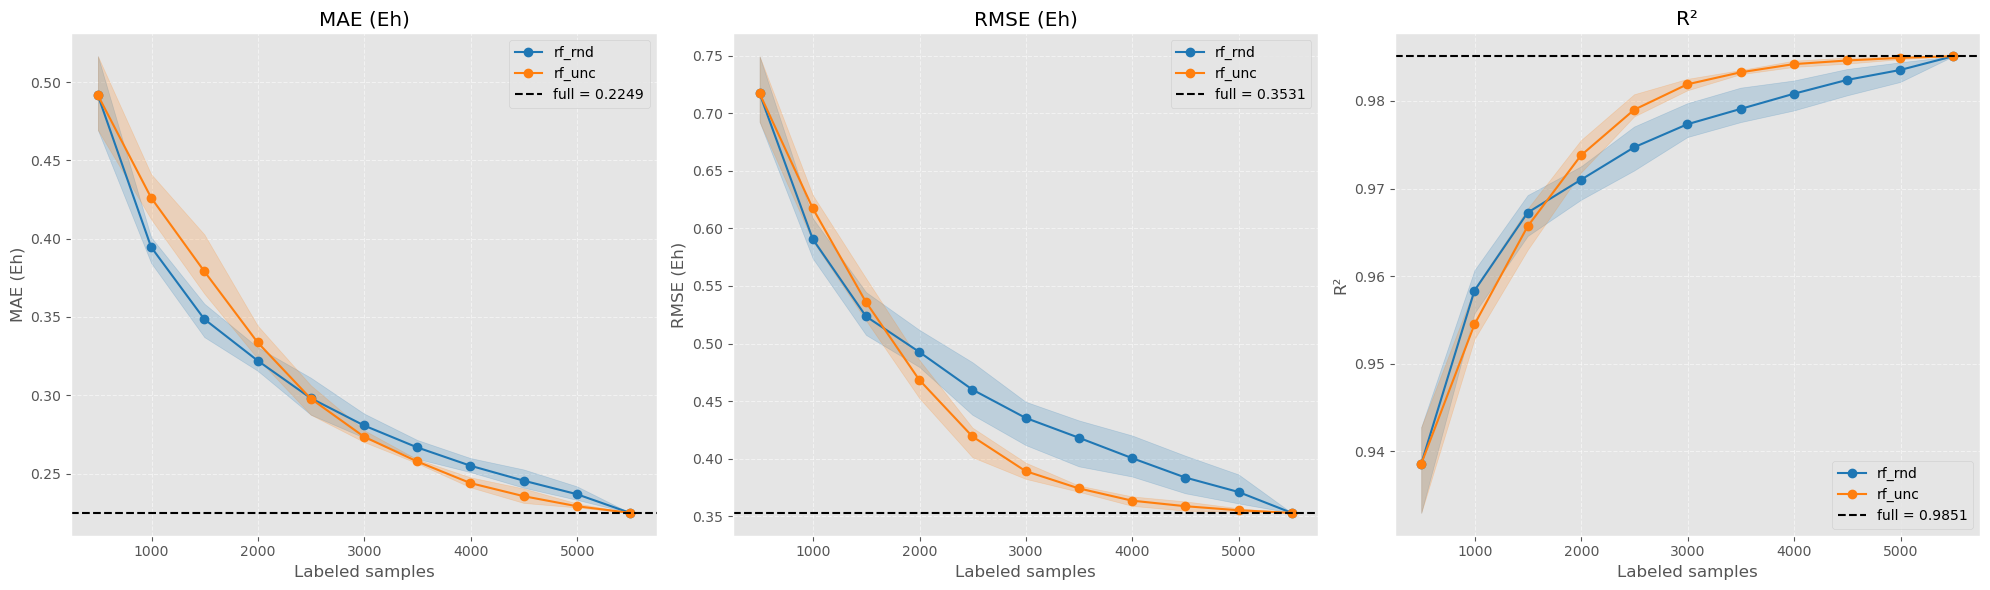

In [67]:
plot_al([rf_rnd, rf_unc], ['rf_rnd','rf_unc'], rf_score, save='active_learning/rf/hse_df_feat/al_rf_dG_hse_df_feat.pdf', format='pdf')

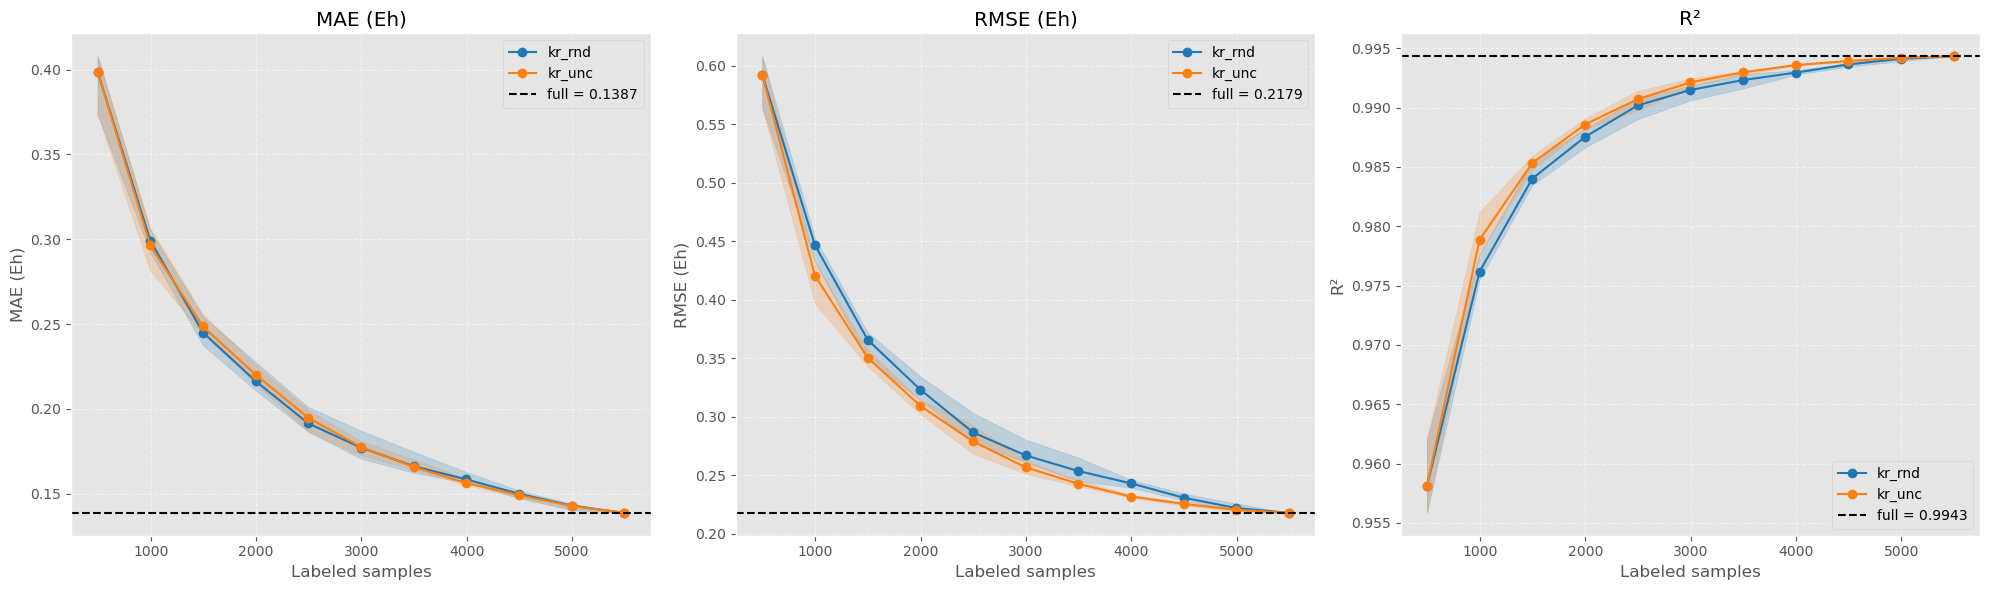

In [66]:
plot_al([kr_rnd, kr_unc], ['kr_rnd','kr_unc'], kr_score, save='active_learning/kr/hse_df_feat/al_kr_dG_hse_df_feat.pdf', format='pdf')

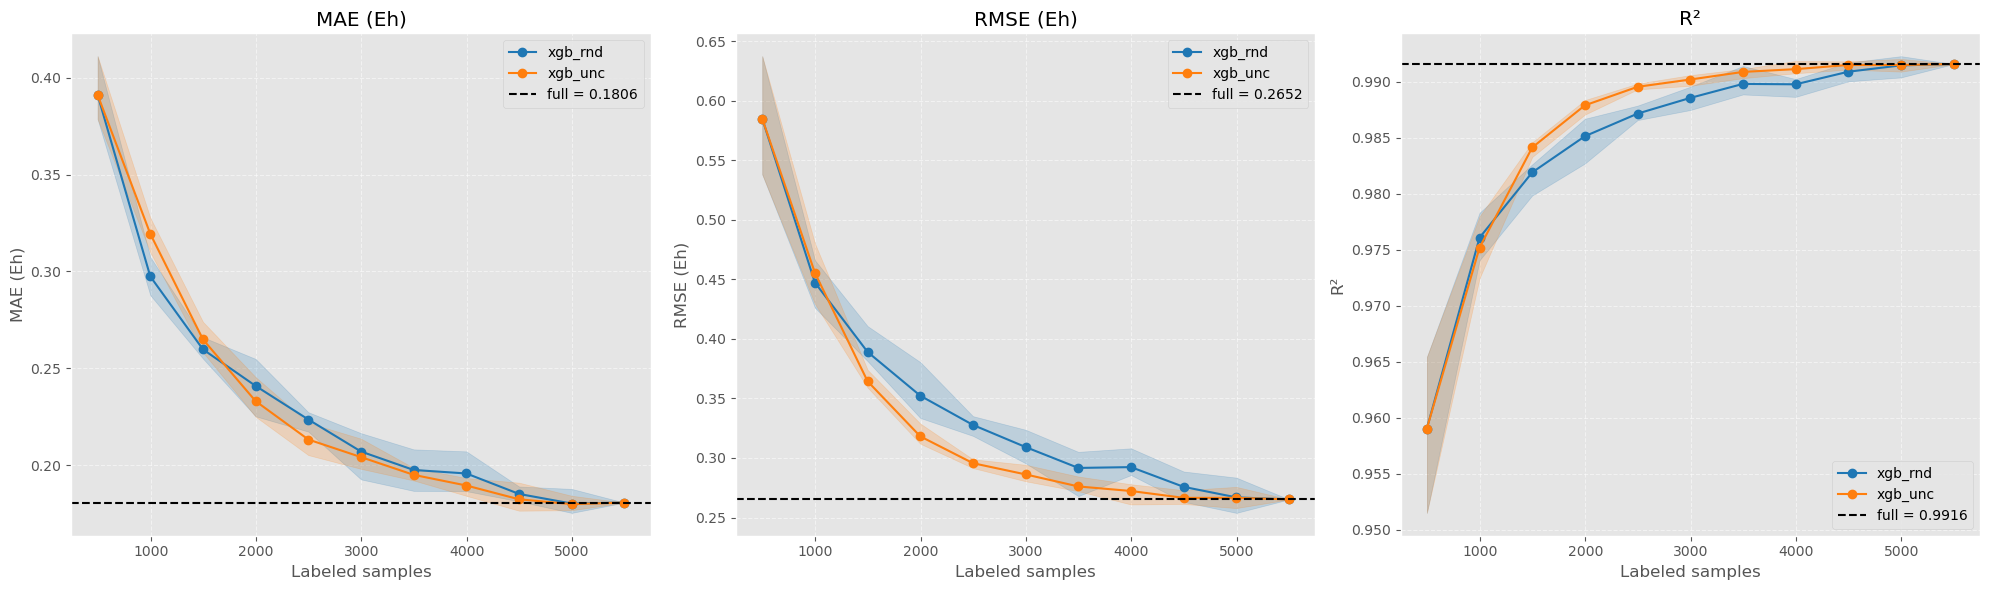

In [65]:
plot_al([xgb_rnd, xgb_unc], ['xgb_rnd','xgb_unc'], xgb_score, save='active_learning/xgb/hse_df_feat/al_xgb_dG_hse_df_feat.pdf', format='pdf')

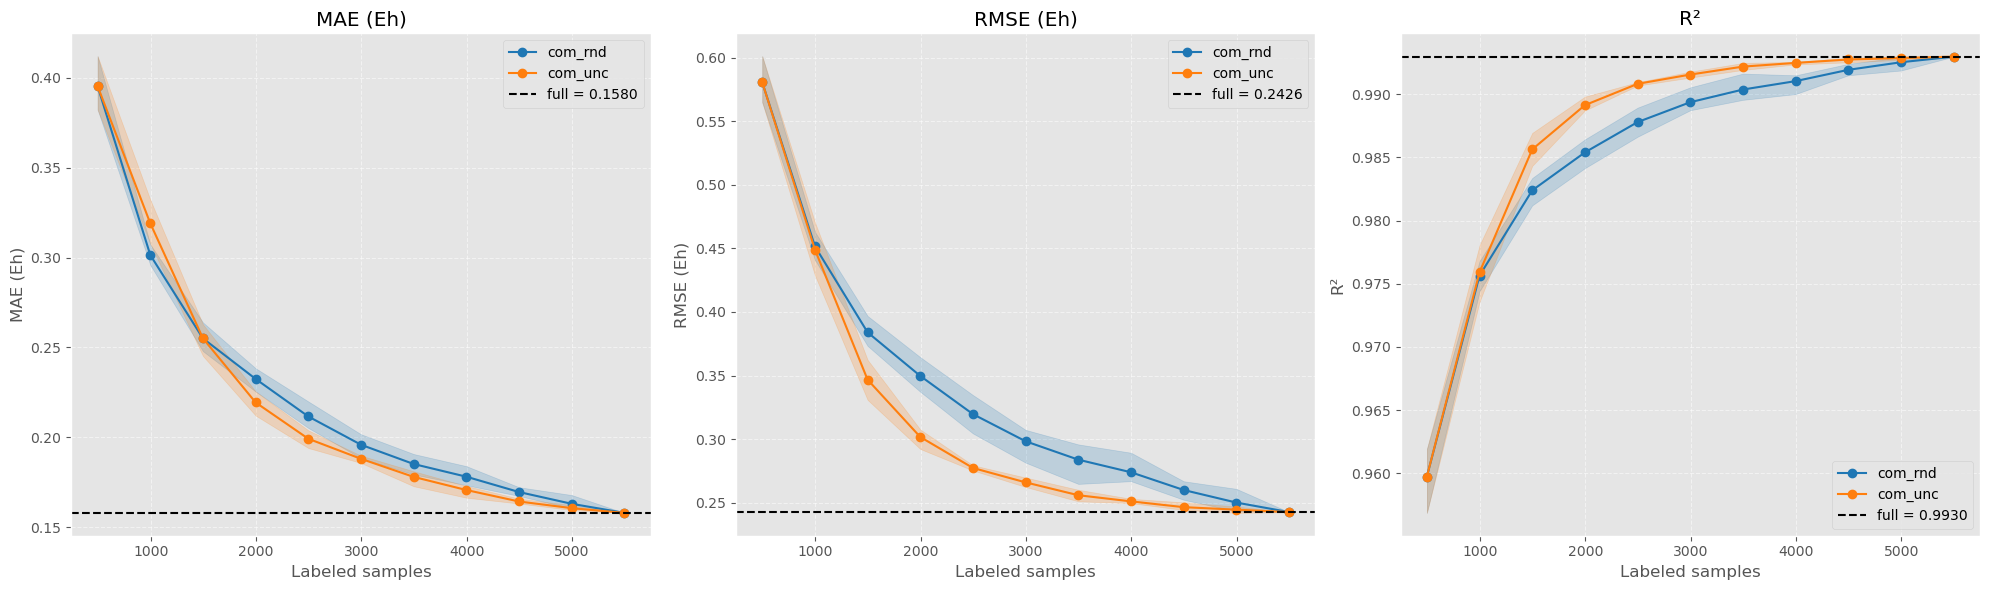

In [64]:
plot_al([com_rnd, com_unc], ['com_rnd','com_unc'], com_score, save='active_learning/com/hse_df_feat/al_com_dG_hse_df_feat.pdf', format='pdf')

In [69]:
import ast
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

print('Computing UMAP projection for X_train...')

reducer = umap.UMAP(
    n_neighbors=25, 
    min_dist=0.05, 
    metric='jaccard', 
    random_state=42
)
X_umap = reducer.fit_transform(X_train)

print('UMAP Projection complete.')

Computing UMAP projection for X_train...
UMAP Projection complete.


In [70]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

# ── PARAMETERS & CONFIGURATION ────────────────────────────────────────────────
CSV_PATH = 'active_learning/com/hse_df_feat/al_history_com_rnd_dG_hse_df_feat.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/com/hse_df_feat/umap_al_com_rnd_dG_hse_df_feat.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# ── MAIN ANIMATION LOOP ───────────────────────────────────────────────────────
frame_files = []

for i, (current_cycle, current_batch) in enumerate(parsed_cycles):
    # Retrieve and separate historically labeled vs. newly queried points
    previous_indices = []
    for cycle_num, indices in parsed_cycles[:i]:
        previous_indices.extend(indices)
    
    total_labeled_count = len(previous_indices) + len(current_batch)

    # Initialize a perfect square canvas
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    
    # Layer 1: Background Density Map (Log scaled)
    hb = ax.hexbin(
        X_umap[:, 0],
        X_umap[:, 1],
        gridsize=60,
        cmap='copper_r',
        mincnt=1,
        edgecolors='none',
        norm=colors.LogNorm()
    )

    # Layer 2: Previously Labeled points (Colored by ground-truth property)
    sc = ax.scatter(
        X_umap[previous_indices, 0],
        X_umap[previous_indices, 1],
        c=y_train[previous_indices],
        cmap='viridis',
        vmin=0.0,
        vmax=0.7,
        marker='o',
        edgecolors='none',
        s=10,
        alpha=0.7,
        label='Previously Labeled',
    )

    # Layer 3: Newly Labeled Points (A acquisition target highlighted in pink)
    ax.scatter(
        X_umap[current_batch, 0],
        X_umap[current_batch, 1],
        c='#FF0055',
        marker='o',
        s=4,
        alpha=0.5,
        label='Newly Labeled',
    )

    # Align 1:1 coordinate spans to keep the physical aspect ratio square
    x_min, x_max = X_umap[:, 0].min(), X_umap[:, 0].max()
    y_min, y_max = X_umap[:, 1].min(), X_umap[:, 1].max()
    limit_min = min(x_min, y_min) - 0.5
    limit_max = max(x_max, y_max) + 0.5
    
    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    ax.set_aspect('equal', adjustable='box')

    # Position colorbars using relative canvas coordinates
    ax_cb_horizontal = ax.inset_axes([0.1, -0.07, 0.8, 0.03])
    cb_density = fig.colorbar(hb, cax=ax_cb_horizontal, orientation='horizontal')
    cb_density.set_label('Molecule Density (Count per Hex)', fontsize=10, fontweight='bold')
    
    ax_cb_vertical = ax.inset_axes([1.03, 0.1, 0.03, 0.8])
    cb_gap = fig.colorbar(sc, cax=ax_cb_vertical)
    cb_gap.set_label('HOMO-LUMO Gap (eV)', fontsize=10, fontweight='bold')

    # Titles and Legends
    ax.set_title(
        f'QM9 Chemical Space (UMAP)\n'
        f'Run {TARGET_RUN} | Cycle {current_cycle} | {total_labeled_count} Total Labeled',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    
    ax.legend(
        loc='upper right', 
        scatterpoints=1, 
        markerscale=1.5, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=9
    )

    # plt.show()
    # Save current cycle plot frame
    frame_path = os.path.join(FRAME_DIR, f'frame_{current_cycle:03d}.png')
    plt.savefig(frame_path, dpi=150) # Use 150 DPI for faster writing
    plt.close(fig)
    
    frame_files.append(frame_path)
    print(f'Rendered Frame for Cycle {current_cycle}')

# ── STEP 5: COMPILING INDIVIDUAL FRAMES INTO A GIF ───────────────────────────
print("Compiling global GIF animation...")
images = [imageio.imread(f) for f in frame_files]
imageio.mimsave(GIF_OUTPUT, images, fps=FPS)

# Optional cleanup: Delete temporary PNG frame files
for f in frame_files:
    os.remove(f)

print(f"Success! Saved evolution animation to: '{GIF_OUTPUT}'")

Rendered Frame for Cycle 1
Rendered Frame for Cycle 2
Rendered Frame for Cycle 3
Rendered Frame for Cycle 4
Rendered Frame for Cycle 5
Rendered Frame for Cycle 6
Rendered Frame for Cycle 7
Rendered Frame for Cycle 8
Rendered Frame for Cycle 9
Rendered Frame for Cycle 10
Rendered Frame for Cycle 11
Compiling global GIF animation...
Success! Saved evolution animation to: 'active_learning/com/hse_df_feat/umap_al_com_rnd_dG_hse_df_feat.gif'


### Violins plots

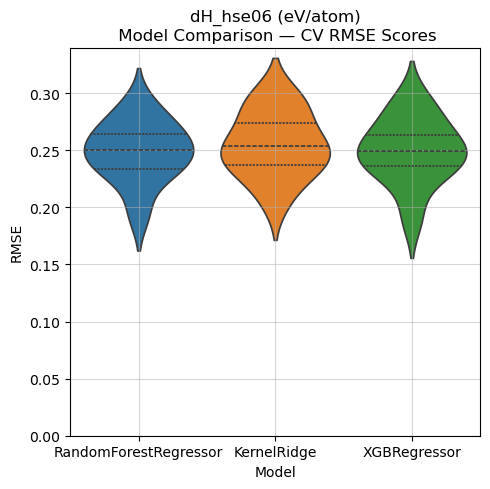

In [34]:
models_1 = [rf_1, kr_1, xgb_1]
make_violin_plot_rmse(X, y1, models_1)

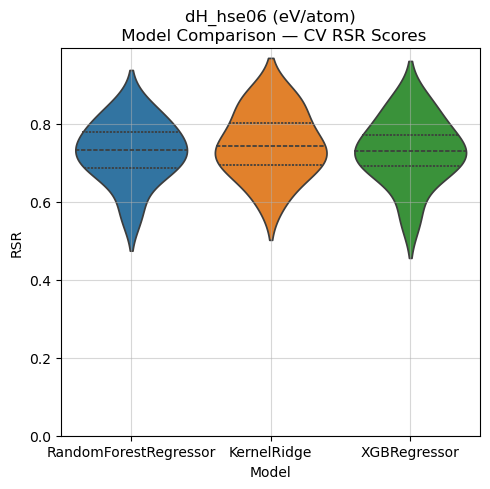

In [35]:
make_violin_plot_rsr(X, y1, models_1)

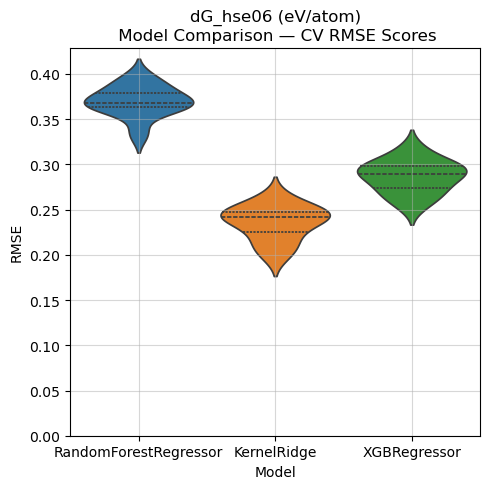

In [36]:
models_2 = [rf_2, kr_2, xgb_2]
make_violin_plot_rmse(X, y2, models_2)

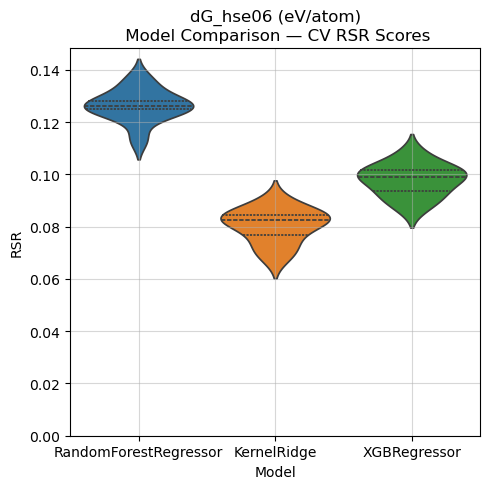

In [37]:
make_violin_plot_rsr(X, y2, models_2)